# Ethiopia Climate Data Profiling, Cleaning, and EDA

This notebook profiles daily NASA POWER weather observations for Addis Ababa, Ethiopia from January 2015 through March 2026. It prepares a cleaned local export for downstream climate trend analysis while keeping data files out of Git.

## Analysis Plan

1. Load daily climate data from the NASA POWER API.
2. Profile shape, missing values, duplicates, date coverage, and implausible values.
3. Clean and engineer analysis-ready date features.
4. Export the cleaned dataset locally to `data/processed/ethiopia_daily_cleaned.csv`.
5. Visualize rainfall, temperature, and seasonal patterns with short interpretations.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for directory in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

COUNTRY = "Ethiopia"
LOCATION = "Addis Ababa"
LATITUDE = 8.9806
LONGITUDE = 38.7578
START_DATE = "20150101"
END_DATE = "20260331"
PARAMETERS = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]

## Load Dataset

The dataset is loaded from NASA POWER and cached locally under `data/raw/`. The raw cache is ignored by Git so the repository stays lightweight and reproducible.

In [2]:
raw_path = RAW_DIR / "ethiopia_addis_ababa_nasa_power_daily_2015_2026.csv"

if raw_path.exists():
    climate_raw = pd.read_csv(raw_path, parse_dates=["date"])
else:
    endpoint = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": ",".join(PARAMETERS),
        "community": "AG",
        "longitude": LONGITUDE,
        "latitude": LATITUDE,
        "start": START_DATE,
        "end": END_DATE,
        "format": "JSON",
    }
    response = requests.get(endpoint, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()["properties"]["parameter"]
    climate_raw = pd.DataFrame(payload).rename_axis("date").reset_index()
    climate_raw["date"] = pd.to_datetime(climate_raw["date"], format="%Y%m%d")
    climate_raw.to_csv(raw_path, index=False)

climate_raw.head()

,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M
0,2015-01-01,11.73,22.75,3.44,0.0,41.79,2.73
1,2015-01-02,12.30,24.01,4.09,0.0,33.29,2.39
2,2015-01-03,12.49,24.17,3.97,0.0,33.83,1.77
3,2015-01-04,14.08,23.78,6.90,0.0,38.84,0.87
4,2015-01-05,14.06,23.15,7.32,0.0,47.07,1.34


## Initial Profile

This section checks dimensions, date coverage, duplicate dates, missingness, and basic descriptive statistics before any cleaning decisions are made.

In [3]:
profile_summary = pd.DataFrame({
    "metric": ["rows", "columns", "start_date", "end_date", "duplicate_dates"],
    "value": [
        len(climate_raw),
        climate_raw.shape[1],
        climate_raw["date"].min().date(),
        climate_raw["date"].max().date(),
        climate_raw["date"].duplicated().sum(),
    ],
})

missing_summary = climate_raw.isna().sum().rename("missing_count").to_frame()
display(profile_summary)
display(missing_summary)
display(climate_raw.describe().T)

,metric,value
0,rows,4108
1,columns,7
2,start_date,2015-01-01
3,end_date,2026-03-31
4,duplicate_dates,0


,missing_count
date,0
T2M,0
T2M_MAX,0
T2M_MIN,0
PRECTOTCORR,0
RH2M,0
WS2M,0


,count,mean,min,25%,50%,75%,max,std
date,4108,2020-08-15 12:00:00,2015-01-01 00:00:00,2017-10-23 18:00:00,2020-08-15 12:00:00,2023-06-08 06:00:00,2026-03-31 00:00:00,NaN
T2M,4108.0,16.069326,10.03,14.82,16.05,17.36,21.53,1.896631
T2M_MAX,4108.0,23.200256,16.16,21.11,22.74,25.18,30.93,2.74882
T2M_MIN,4108.0,10.228651,1.17,8.4175,10.985,12.23,15.68,2.608968
PRECTOTCORR,4108.0,3.639413,0.0,0.02,0.82,4.5825,82.3,6.303272
RH2M,4108.0,68.435034,14.42,59.08,71.185,80.79,91.93,14.720017
WS2M,4108.0,1.982522,0.46,1.41,1.97,2.48,4.13,0.689174


## Clean and Prepare Data

NASA POWER missing values can be encoded as `-999`. The cleaning step replaces those sentinels with missing values, removes duplicate dates, sorts the time series, fills small numeric gaps with time interpolation, and adds calendar fields for monthly and annual analysis.

In [4]:
climate = climate_raw.copy()
climate.columns = climate.columns.str.lower()
climate = climate.replace(-999, np.nan)
climate = climate.drop_duplicates(subset="date").sort_values("date")
climate = climate.set_index("date").asfreq("D")

numeric_cols = climate.select_dtypes(include="number").columns
climate[numeric_cols] = climate[numeric_cols].interpolate(method="time", limit_direction="both")

climate = climate.reset_index()
climate["country"] = COUNTRY
climate["location"] = LOCATION
climate["year"] = climate["date"].dt.year
climate["month"] = climate["date"].dt.month
climate["month_name"] = climate["date"].dt.month_name().str[:3]
climate["season"] = climate["month"].map({
    12: "Bega", 1: "Bega", 2: "Bega",
    3: "Belg", 4: "Belg", 5: "Belg",
    6: "Kiremt", 7: "Kiremt", 8: "Kiremt", 9: "Kiremt",
    10: "Tseday", 11: "Tseday",
})

clean_path = PROCESSED_DIR / "ethiopia_daily_cleaned.csv"
climate.to_csv(clean_path, index=False)

print(f"Cleaned data exported locally to: {clean_path}")
display(climate.head())
display(climate.isna().sum().rename("missing_after_cleaning").to_frame())

Cleaned data exported locally to: C:\Users\Administrator\Documents\Codex\2026-04-29\files-mentioned-by-the-user-african\climate-challenge-week0\data\processed\ethiopia_daily_cleaned.csv


,date,t2m,t2m_max,t2m_min,prectotcorr,rh2m,ws2m,country,location,year,month,month_name,season
0,2015-01-01,11.73,22.75,3.44,0.0,41.79,2.73,Ethiopia,Addis Ababa,2015,1,Jan,Bega
1,2015-01-02,12.30,24.01,4.09,0.0,33.29,2.39,Ethiopia,Addis Ababa,2015,1,Jan,Bega
2,2015-01-03,12.49,24.17,3.97,0.0,33.83,1.77,Ethiopia,Addis Ababa,2015,1,Jan,Bega
3,2015-01-04,14.08,23.78,6.90,0.0,38.84,0.87,Ethiopia,Addis Ababa,2015,1,Jan,Bega
4,2015-01-05,14.06,23.15,7.32,0.0,47.07,1.34,Ethiopia,Addis Ababa,2015,1,Jan,Bega


,missing_after_cleaning
date,0
t2m,0
t2m_max,0
t2m_min,0
prectotcorr,0
rh2m,0
ws2m,0
country,0
location,0
year,0


## Annual Temperature Trend

The annual mean temperature plot smooths daily variability into year-level signals. Any persistent upward or downward movement here is more useful for climate trend discussion than individual daily extremes.

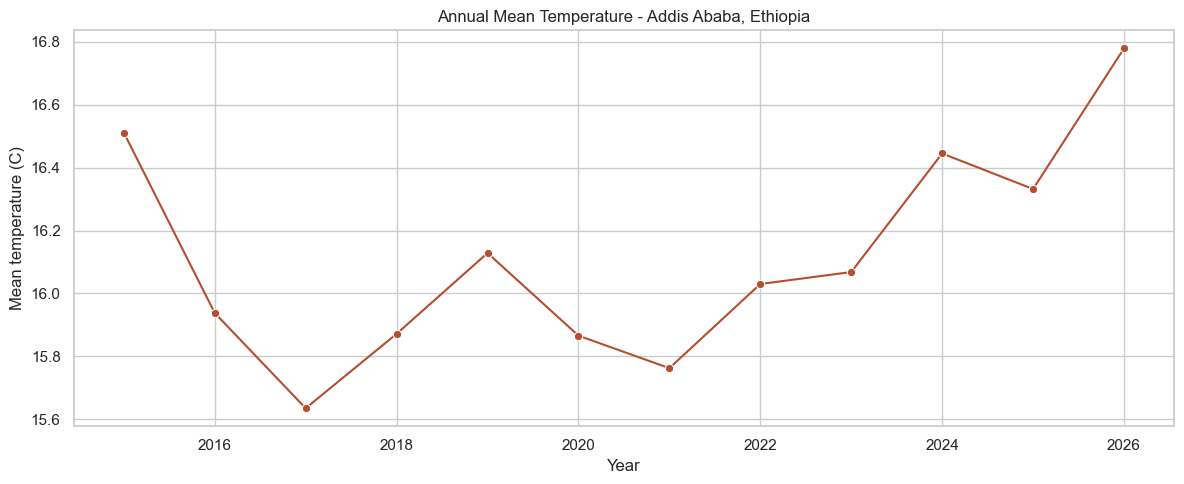

,year,mean_temperature_c
0,2015,16.511041
1,2016,15.937705
2,2017,15.635068
3,2018,15.871671
4,2019,16.128548
5,2020,15.865874
6,2021,15.762493
7,2022,16.030055
8,2023,16.068055
9,2024,16.445000


In [5]:
annual_temperature = climate.groupby("year", as_index=False).agg(mean_temperature_c=("t2m", "mean"))

ax = sns.lineplot(data=annual_temperature, x="year", y="mean_temperature_c", marker="o", color="#b44e2f")
ax.set_title("Annual Mean Temperature - Addis Ababa, Ethiopia")
ax.set_xlabel("Year")
ax.set_ylabel("Mean temperature (C)")
plt.tight_layout()
plt.show()

annual_temperature

**Interpretation:** Annual mean temperature varies within a narrow range for Addis Ababa, which is expected for a highland location. The incomplete 2026 period should be interpreted cautiously because it only covers January through March.

## Monthly Rainfall Seasonality

Monthly precipitation totals reveal the seasonal rainfall cycle. This is important for identifying whether the rainy season dominates annual water availability.

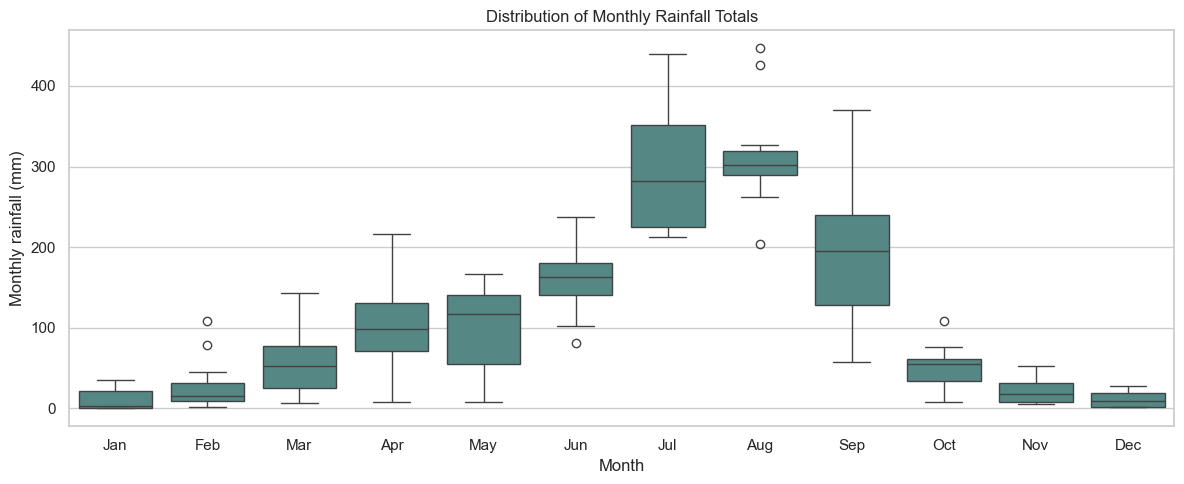

In [6]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_rain = climate.groupby(["year", "month", "month_name"], as_index=False).agg(monthly_rain_mm=("prectotcorr", "sum"))

ax = sns.boxplot(data=monthly_rain, x="month_name", y="monthly_rain_mm", order=month_order, color="#4d8f8b")
ax.set_title("Distribution of Monthly Rainfall Totals")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly rainfall (mm)")
plt.tight_layout()
plt.show()

**Interpretation:** Rainfall is concentrated in the mid-year Kiremt months, while the dry Bega period contributes much less precipitation. This pattern supports a seasonal framing for later drought or rainfall anomaly analysis.

## Temperature and Rainfall Relationship

A scatter plot of daily temperature and rainfall helps show whether wetter days tend to coincide with cooler or warmer conditions.

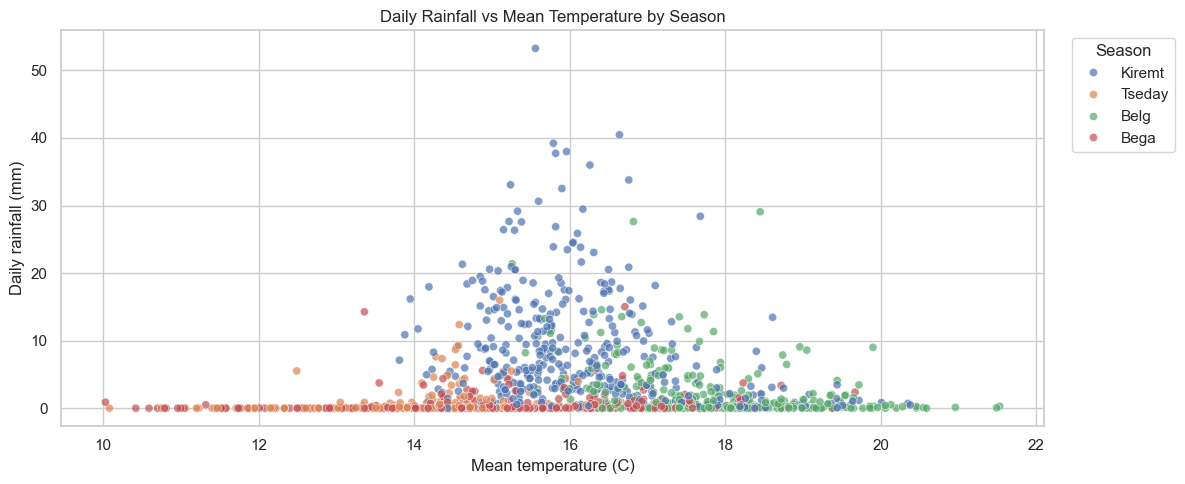

In [7]:
sample = climate.sample(min(1200, len(climate)), random_state=42)
ax = sns.scatterplot(data=sample, x="t2m", y="prectotcorr", hue="season", alpha=0.7, s=35)
ax.set_title("Daily Rainfall vs Mean Temperature by Season")
ax.set_xlabel("Mean temperature (C)")
ax.set_ylabel("Daily rainfall (mm)")
plt.legend(title="Season", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** High-rainfall days cluster mainly in the rainy season. The relationship is not purely linear, so later modeling should include seasonal features instead of relying only on temperature to explain rainfall.

## Cleaned Export Check

The final check confirms that the cleaned local export exists. The repository `.gitignore` excludes CSV files and all generated data under `data/`, so this export provides local evidence without committing data files.

In [8]:
export_check = pd.DataFrame({
    "path": [str(clean_path.relative_to(PROJECT_ROOT))],
    "exists": [clean_path.exists()],
    "rows": [len(pd.read_csv(clean_path)) if clean_path.exists() else 0],
})
export_check

,path,exists,rows
0,data\processed\ethiopia_daily_cleaned.csv,True,4108
